### Small Image Classification Using Convolutional Neural Network (CNN)

In this notebook, we will classify small images cifar10 dataset from tensorflow keras datasets. There are total 10 classes as shown below. We will use CNN for classification

<img src="small_images.jpg" />

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

Load the dataset

In [4]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

Here we see there are 50000 training images and 1000 test images

In [5]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

y_train is a 2D array, for our classification having 1D array is good enough. so we will convert this to now 1D array

In [5]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [6]:
y_test = y_test.reshape(-1,)

In [7]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

Let's plot some images to see what they are 

In [ ]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

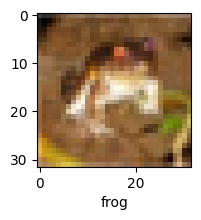

In [10]:
# plot first index image from training set
plot_sample(X_train, y_train, 0)

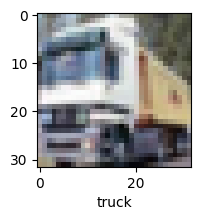

In [11]:
plot_sample(X_train, y_train, 1)

Normalize the images to a number from 0 to 1. Image has 3 channels (R,G,B) and each value in the channel can range from 0 to 255. Hence to normalize in 0-->1 range, we need to divide it by 255

### Normalizing the training data

In [12]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Build simple artificial neural network (ANN) for image classification

In [14]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')    
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.3078 - loss: 1.9223
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.4241 - loss: 1.6415
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.4516 - loss: 1.5499
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.4731 - loss: 1.4920
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.4959 - loss: 1.4325
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5180 - loss: 1.3830
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5244 - loss: 1.3474
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.5418 - loss: 1.3135
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.5533 - loss: 1.2782
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5587 - loss: 1.2520


**We can see that at the end of 10 epochs, accuracy is at around ~56%**

In [15]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.62      0.54      0.57      1000
           1       0.60      0.68      0.64      1000
           2       0.39      0.42      0.40      1000
           3       0.43      0.21      0.28      1000
           4       0.48      0.43      0.45      1000
           5       0.53      0.31      0.39      1000
           6       0.50      0.69      0.58      1000
           7       0.60      0.56      0.58      1000
           8       0.54      0.73      0.62      1000
           9       0.50      0.65      0.56      1000

    accuracy                           0.52     10000
   macro avg       0.52      0.52      0.51     10000
weighted avg       0.52      0.52      0.51     10000



Now let us build a convolutional neural network (CNN) to train our images


In [16]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Workspace\MyProjects\DeepLearning\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [27]:
cnn.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7864 - loss: 0.6065 - val_accuracy: 0.6869 - val_loss: 0.9598
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7987 - loss: 0.5701 - val_accuracy: 0.6860 - val_loss: 0.9699
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8078 - loss: 0.5453 - val_accuracy: 0.6930 - val_loss: 0.9678
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8193 - loss: 0.5114 - val_accuracy: 0.6842 - val_loss: 1.0237
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8297 - loss: 0.4861 - val_accuracy: 0.6907 - val_loss: 1.0129
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8350 - loss: 0.4761 - val_accuracy: 0.6858 - val_loss: 1.0603
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8475 - loss: 0.4389 - val_accuracy: 0.6861 - val_loss: 1.0778
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8505 - loss:

**With CNN, at the end 10 epochs, accuracy was at around ~86~% which is a significant improvement over ANN. CNN's are best for image classification and gives superb accuracy. Also computation is much less compared to simple ANN as maxpooling reduces the image dimensions while still preserving the features**

In [28]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6791 - loss: 1.1829


[1.175085186958313, 0.6780999898910522]

With the X_test data, our model accuracy is 67%

In [29]:
y_pred = cnn.predict(X_test)

y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]
print(f"Pricted values for first 5 samples: {np.array((y_classes[:5]))}")
print(f"Actual values for first 5 samples: {np.array(y_test[:5])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Pricted values for first 5 samples: [3 8 8 0 6]
Actual values for first 5 samples: [3 8 8 0 6]


Predicted valued of index 3 is: airplane
Actual valued of index 3 is: airplane


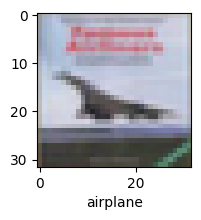

In [30]:
# seems the 3rd and 4th index images are misclassified, let see it
check_index_value = 3
plot_sample(X_test, y_test,check_index_value)
print(f"Predicted valued of index {check_index_value} is: {classes[y_classes[check_index_value]]}")
print(f"Actual valued of index {check_index_value} is: {classes[y_test[check_index_value]]}")

# Lets check at index 8

Predicted valued of index 8 is: cat
Actual valued of index 8 is: cat


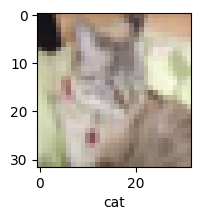

In [31]:
check_index_value = 8
plot_sample(X_test, y_test,check_index_value)
print(f"Predicted valued of index {check_index_value} is: {classes[y_classes[check_index_value]]}")
print(f"Actual valued of index {check_index_value} is: {classes[y_test[check_index_value]]}")  

Lets run for more epoches with EarlyStopping

In [32]:
# Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
cnn.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8704 - loss: 0.3683 - val_accuracy: 0.6847 - val_loss: 1.1754
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8788 - loss: 0.3475 - val_accuracy: 0.6778 - val_loss: 1.2428
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8768 - loss: 0.3439 - val_accuracy: 0.6740 - val_loss: 1.2863
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8872 - loss: 0.3163 - val_accuracy: 0.6691 - val_loss: 1.3457


In [33]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6827 - loss: 1.1791


[1.1754169464111328, 0.6847000122070312]

Predicted valued of index 4 is: frog
Actual valued of index 4 is: frog


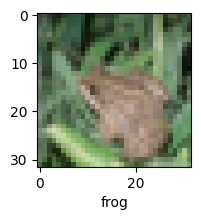

In [34]:
check_index_value = 4
plot_sample(X_test, y_test,check_index_value)
print(f"Predicted valued of index {check_index_value} is: {classes[y_classes[check_index_value]]}")
print(f"Actual valued of index {check_index_value} is: {classes[y_test[check_index_value]]}")  

Predicted valued of index 10 is: airplane
Actual valued of index 10 is: airplane


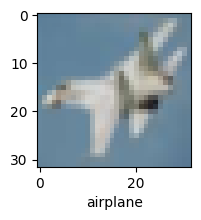

In [35]:
check_index_value = 10
plot_sample(X_test, y_test,check_index_value)
print(f"Predicted valued of index {check_index_value} is: {classes[y_classes[check_index_value]]}")
print(f"Actual valued of index {check_index_value} is: {classes[y_test[check_index_value]]}") 